In [1]:
# Controlling cpu usage
import os
os.environ["NUMBA_NUM_THREADS"] = "6"
os.environ["OMP_NUM_THREADS"] = "6"
os.environ["MKL_NUM_THREADS"] = "6"

In [2]:
import scanpy as sc
import anndata as ad

In [ ]:
brain_vascular = sc.read_h5ad("../brain_vascular.h5ad")

In [ ]:
# Print the author annotations of cell types and the number of cells in each type
print(brain_vascular.obs["author_cell_type"].value_counts())
print(brain_vascular.var.head())
print(brain_vascular.layers.keys())

author_cell_type
Microglia                         10092
Capillary                          8620
Smooth_Muscle_Cell                 7952
Arterial                           7388
Oligodendrocyte                    6221
Perivascular_Fibroblast            5104
Venous                             4112
Pericyte                           3877
Excitatory_Neuron                  3583
Meningeal_Fibroblast               2529
Inhibitory_Neuron                  1667
Astrocyte                          1482
T_cells                            1217
Perivascular_Macrophage            1044
Oligodendrocyte_Precursor_Cell      591
Name: count, dtype: int64
                      names       ensembl_id       feature_id  \
ENSG00000241860  AL627309.5  ENSG00000241860  ENSG00000241860   
ENSG00000237491   LINC01409  ENSG00000237491  ENSG00000237491   
ENSG00000228794   LINC01128  ENSG00000228794  ENSG00000228794   
ENSG00000225880   LINC00115  ENSG00000225880  ENSG00000225880   
ENSG00000230368      FAM41C  ENS

In [4]:
# Instead of using processed data, we can directly use the raw data for downstream analysis
adata = brain_vascular.raw.to_adata()
print(adata.obs.head())
print(adata.obs.columns)
print(adata.obs['cell_type'].value_counts())

                            author_cell_type cell_type_ontology_term_id  \
A42#AAACAGCCAGAACCGA-1  Meningeal_Fibroblast                 CL:0000057   
A42#AAACAGCCAGCAATAA-1              Pericyte                 CL:0000669   
A42#AAACATGCAACTAGGG-1             Microglia                 CL:0000129   
A42#AAACATGCAATTTAGC-1       Oligodendrocyte                 CL:0000128   
A42#AAACCAACATGGAGGC-1  Meningeal_Fibroblast                 CL:0000057   

                       donor_id development_stage_ontology_term_id  \
A42#AAACAGCCAGAACCGA-1      A42                     HsapDv:0000274   
A42#AAACAGCCAGCAATAA-1      A42                     HsapDv:0000274   
A42#AAACATGCAACTAGGG-1      A42                     HsapDv:0000274   
A42#AAACATGCAATTTAGC-1      A42                     HsapDv:0000274   
A42#AAACCAACATGGAGGC-1      A42                     HsapDv:0000274   

                       sex_ontology_term_id disease_ontology_term_id  \
A42#AAACAGCCAGAACCGA-1         PATO:0000383            M

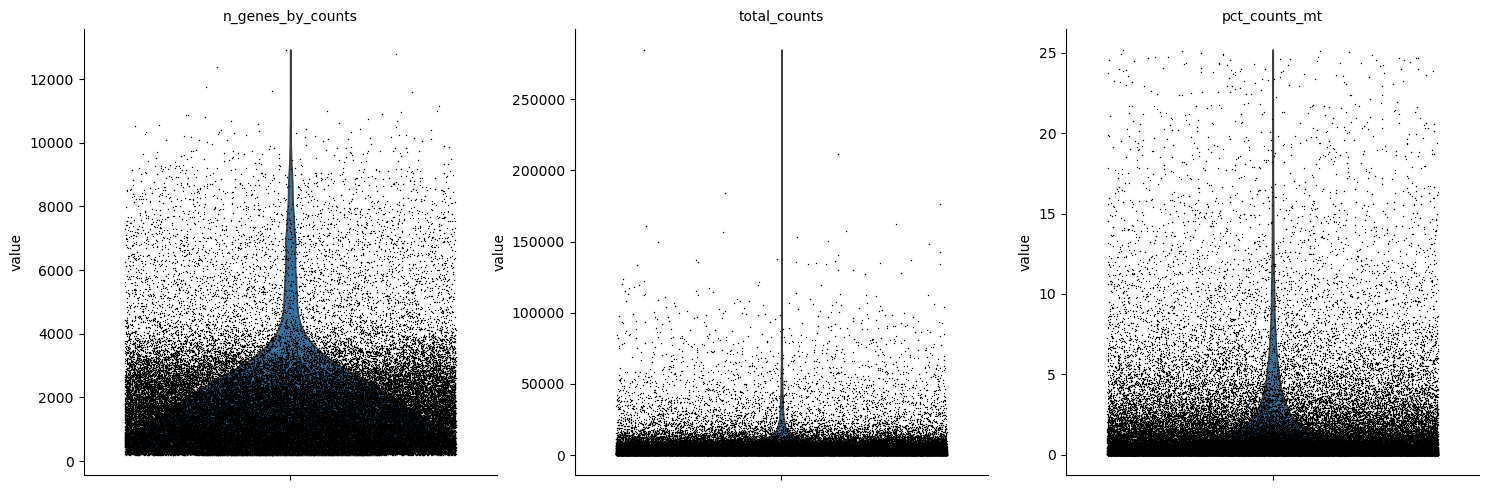

In [5]:
# Adding mitochondrial gene annotation
adata.var["mt"] = adata.var["feature_name"].str.upper().str.startswith("MT-")
# Calculating QC metrics
sc.pp.calculate_qc_metrics(
    adata,
    qc_vars=["mt"],
    inplace=True
)

sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'], jitter=0.4, multi_panel=True)

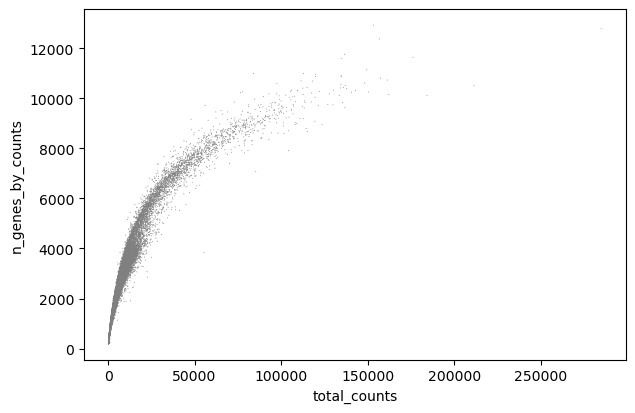

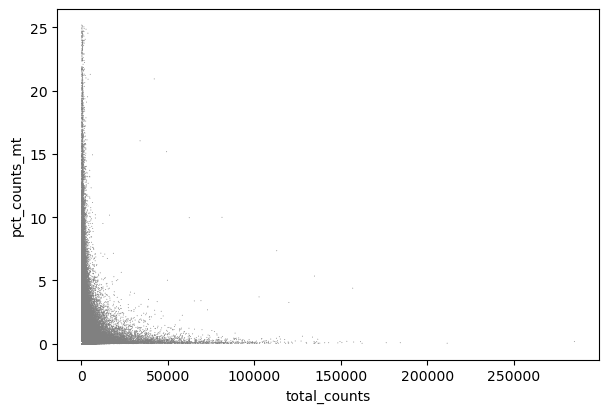

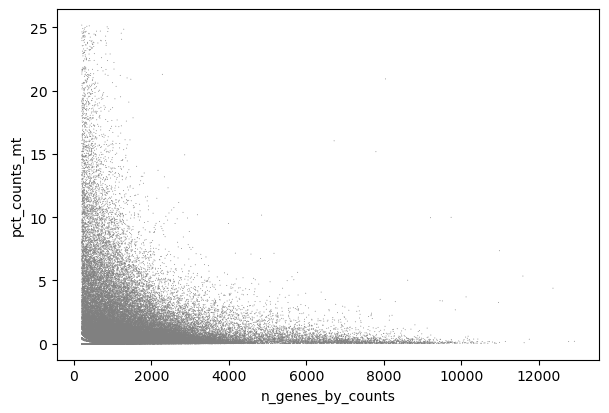

In [ ]:
# Checking scatter plots and quantiles to set thresholds
sc.pl.scatter(adata, x="total_counts", y="n_genes_by_counts")
sc.pl.scatter(adata, x="total_counts", y="pct_counts_mt")
sc.pl.scatter(adata, x="n_genes_by_counts", y="pct_counts_mt")
adata.obs[
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"]
].describe(percentiles=[0.01, 0.05, 0.5, 0.95, 0.98, 0.99])

In [6]:
# Setting threshold
print("Before filtering:", adata.n_obs)
# Filtering cells based on QC metrics
adata_qc = adata[
    (adata.obs["n_genes_by_counts"] > 300) &
    (adata.obs["n_genes_by_counts"] < 8000) &
    (adata.obs["total_counts"] < 55000) &
    (adata.obs["pct_counts_mt"] < 15),
    :
].copy()

print("After filtering:", adata_qc.n_obs)
print("Removed:", adata.n_obs - adata_qc.n_obs)

Before filtering: 65479
After filtering: 61497
Removed: 3982


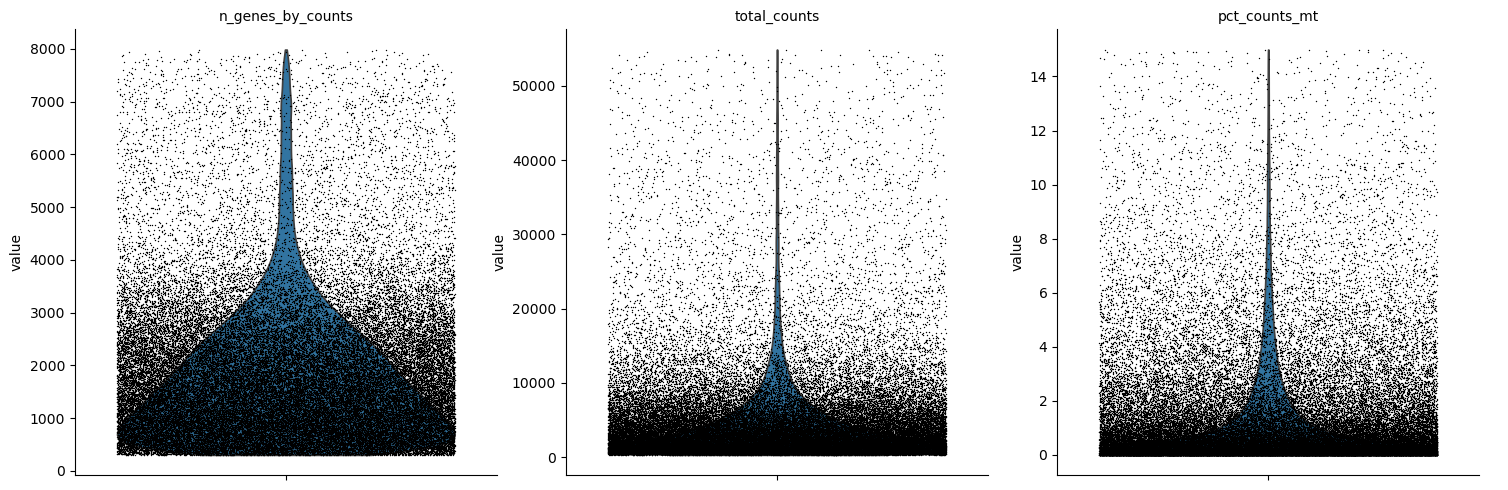

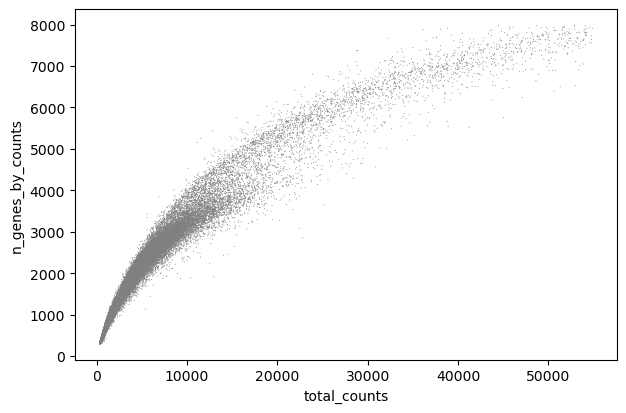

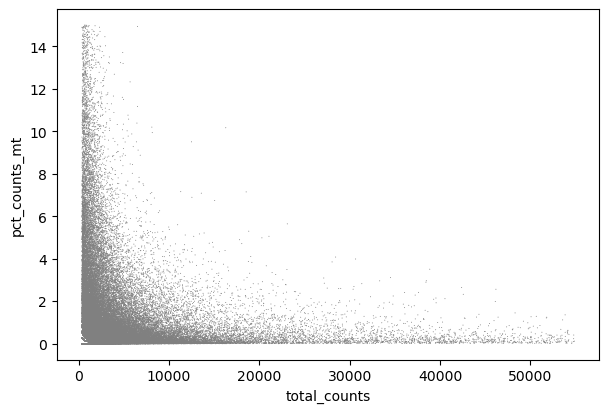

In [ ]:
# Visualize the QC metrics after filtering
sc.pl.violin(
    adata_qc,
    ["n_genes_by_counts", "total_counts", "pct_counts_mt"],
    jitter=0.4,
    multi_panel=True
)

sc.pl.scatter(adata_qc, x="total_counts", y="n_genes_by_counts")
sc.pl.scatter(adata_qc, x="total_counts", y="pct_counts_mt")

In [7]:
# Normalization and log transformation
sc.pp.normalize_total(adata_qc, target_sum=1e4)
sc.pp.log1p(adata_qc)

In [ ]:
# Extracting highly variable genes
sc.pp.highly_variable_genes(adata_qc, n_top_genes=2000, flavor="cell_ranger")
adata_qc = adata_qc[:, adata_qc.var["highly_variable"]].copy()

In [9]:
# Scaling the data
sc.pp.scale(adata_qc, max_value=10, zero_center=False)

In [10]:
# PCA
sc.tl.pca(adata_qc, svd_solver="arpack")

In [ ]:
# Finding neighbors
sc.pp.neighbors(adata_qc, n_neighbors=15, n_pcs=30)

In [12]:
# UMAP
sc.tl.umap(adata_qc)

Index(['author_cell_type', 'cell_type_ontology_term_id', 'donor_id',
       'development_stage_ontology_term_id', 'sex_ontology_term_id',
       'disease_ontology_term_id', 'is_primary_data', 'suspension_type',
       'tissue_ontology_term_id', 'tissue_type', 'assay_ontology_term_id',
       'self_reported_ethnicity_ontology_term_id', 'cell_type', 'assay',
       'disease', 'sex', 'tissue', 'self_reported_ethnicity',
       'development_stage', 'observation_joinid', 'n_genes_by_counts',
       'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts',
       'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes',
       'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes',
       'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt'],
      dtype='object')


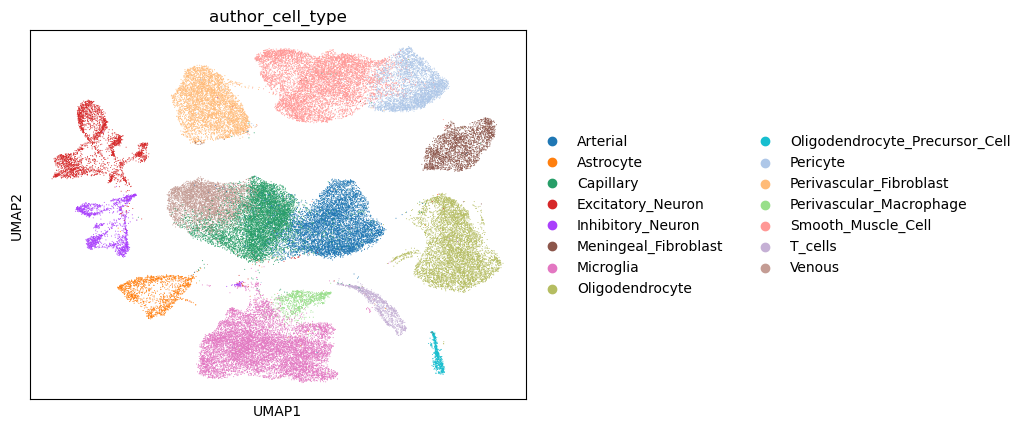

In [13]:
# Plotting UMAP colored by cell type
print(adata_qc.obs.columns)
sc.pl.umap(adata_qc, color="author_cell_type")